In [5]:
# imports
import os
import numpy as np
import tensorflow as tf
from google.cloud import storage
import tempfile
# import cv2
# from drought_detection.params import BUCKET_NAME, BUCKET_TRAIN_DATA_PATH


## AVAILABLE BANDWIDTHS

In [6]:
bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11']

    # features = {
    #     'B1': tf.compat.v1.FixedLenFeature([], tf.string),    # 0.43 - 0.45 μm Coastal aerosol
    #     'B2': tf.compat.v1.FixedLenFeature([], tf.string),    # Blue
    #     'B3': tf.compat.v1.FixedLenFeature([], tf.string),    # Green
    #     'B4': tf.compat.v1.FixedLenFeature([], tf.string),    # Red
    #     'B5': tf.compat.v1.FixedLenFeature([], tf.string),    # Near infrared
    #     'B6': tf.compat.v1.FixedLenFeature([], tf.string),    # Shortwave infrared 1
    #     'B7': tf.compat.v1.FixedLenFeature([], tf.string),    # Shortwave infrared 2
    #     'B8': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'B9': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'B10': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'B11': tf.compat.v1.FixedLenFeature([], tf.string),
    #     'label': tf.compat.v1.FixedLenFeature([], tf.int64),
    #     }

AttributeError: module 'tensorflow' has no attribute 'FixedLenFeature'

# FUNCTIONS

## Get and filter raw satellite data for specific spectral bands

In [22]:
def parse_visual(data):
    '''
    This function filters satellite image data by specific spectral bands (RGB in this case).
    The function loads a batch of satellite images from a list of files
    and parses the satellite image data files for some specific features,
    e.g. spectral bands (B2, B3, B4, see official documentation)

    Input(s): - list of satellite image files (including path, e.g '/data/train/part-r-00000')
    Outputs:  - list of dictionaries of raw satellite data (filtered by spectral band)
    '''
    dataset = tf.data.TFRecordDataset(data)

    iterator = tf.compat.v1.data.make_one_shot_iterator(dataset)

    features = {
        'B1': tf.compat.v1.FixedLenFeature([], tf.string),    # 0.43 - 0.45 μm Coastal aerosol
        'B2': tf.compat.v1.FixedLenFeature([], tf.string),    # Blue
        'B3': tf.compat.v1.FixedLenFeature([], tf.string),    # Green
        'B4': tf.compat.v1.FixedLenFeature([], tf.string),    # Red
        'B5': tf.compat.v1.FixedLenFeature([], tf.string),    # Near infrared
        'B6': tf.compat.v1.FixedLenFeature([], tf.string),    # Shortwave infrared 1
        'B7': tf.compat.v1.FixedLenFeature([], tf.string),    # Shortwave infrared 2
        'B8': tf.compat.v1.FixedLenFeature([], tf.string),
        'B9': tf.compat.v1.FixedLenFeature([], tf.string),
        'B10': tf.compat.v1.FixedLenFeature([], tf.string),
        'B11': tf.compat.v1.FixedLenFeature([], tf.string),
        'label': tf.compat.v1.FixedLenFeature([], tf.int64),
        }
    
    parsed_sat_imgs = [tf.compat.v1.parse_single_example(data, features) for data in iterator]
    return parsed_sat_imgs


## Transform each raw satellite image into an RGB array with label

In [8]:

def get_img_from_example(parsed_sat_img, intensify=True):
    '''
    This function creates an RGB 3D array in shape 65x65x3 (65x65 pixels) for 
    a single parsed satellite image, while also scaling each spectral band. 
    For each band (depends on filtering done by above function),
    the raw band data is transformed from the Tensorflow specific data format into
    a 2D array of dimension 65x65 pixels.
    
    Next, it does some scaling: if intensity=True, it divides each pixel by the
    maximum value of the pixels, and then multiplies it by 255.
    Otherwise, if intensify=False, it just multiplies each pixel in the matrix by 255.
    "When the range of pixel brightness values is closer to 0, a darker image is rendered by default.
    You can stretch the values to extend to the full 0-255 range of potential values to 
    increase the visual contrast of the image."
    - https://www.earthdatascience.org/courses/use-data-open-source-python/multispectral-remote-sensing/landsat-in-Python/
    
    Lastly, the function adds the corresponding label, and returns the image 2D array, as well as the label.
    

    Input: - a parsed satellite image: Specific Tensorflow format (as dictionary)
    Output(s) - satellite image & its label:
                - rgbArray: tuple of 3D numpy array (shape 65x65x3)
                - label: int32
    '''
    rgbArray = np.zeros((65,65,3), 'uint8')
    for i, band in enumerate(['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11']):
        band_data = np.frombuffer(parsed_sat_img[band].numpy(), dtype=np.uint8) # transforms raw tensorflow data into 1D array
        band_data = band_data.reshape(65, 65) # reshapes data into 65 x 65 pixel matrix
        
        print(band_data, band_data.shape) # check values and shape of converted sat image (before scaling)
        plt.figure();
        plt.imshow(band_data).axes.get_xaxis().set_visible(True);
        plt.title('green, blue, red bands (unscaled)');
        
    # if intensify:
        band_data_2 = band_data/np.max(band_data)*255 # are we transforming the image from bytes to digital numbers by multiplying by 255?
        plt.figure();
        plt.imshow(band_data_2).axes.get_xaxis().set_visible(True);
        plt.title('green, blue, red bands (intensified!)');
    # else:
        band_data_3 = band_data*255
        plt.figure();
        plt.imshow(band_data_3).axes.get_xaxis().set_visible(True);
        plt.title('green, blue, red bands (not intensified)');
        
        # still need to figure out what this does (with other functions)
        rgbArray[..., i] = band_data
        
        
        # to do:
        # plot all the bands without intensification in one image

    label = tf.cast(parsed_sat_img['label'], tf.int32).numpy() # gets label for image

    return rgbArray, label


In [ ]:
landsat_post_fire_xr = xr.concat(all_bands, dim="band") 
landsat_post_fire_xr

# Explore data images

In [12]:
# create a function called dirlist that extracts a list of file names (file) from a directory (di)
dirlist = lambda di: [os.path.join(di, file) for file in os.listdir(di) if 'part-' in file]

# get list of files
validation_files = dirlist('../raw_data/val/')

# parse first file (returns image as list of dict)
parsed_examples = parse_visual(validation_files[0])

# parsed_examples[image][band]
parsed_examples[0]['B2']

<tf.Tensor: shape=(), dtype=string, numpy=b'!!!!!!!!##"   #$#"!!"##""""""!!!!!!"!" !"#"##!!!!!!!!!!!""#"###"!!!! !!!!"#$"\x1f\x1d!$#!"!!!"""""!!!!!!!"""!!""#"##!!!!"!!!!!"""""####"\x1f   !!!!""##!\x1e\x1d!%%#!!!!"""  !""!!!!""!!!!####"!!!"!!!!!"""""#""""\x1f\x1f\x1f  !!!"""!!  !!"#"!!!"""!!"#"!"!! !"!!""#$#!!!""!!""""""""""!"!\x1f\x1f   !!"""""!#%% \x1d"#" !!""""""""""! !"! ""#%"!!"!"!!""""""###!!! \x1f\x1f\x1f   !!!#"!!#%$"\x1e\x1f$"!""#""""""#""!!!!"  "$$!!!!!!!"""!""####"!"!\x1f\x1f\x1f\x1f\x1f   !"""""#"! !$$#####"""""##""!"!##!!##"!!! !"""""""####"#"!\x1f\x1f\x1f\x1f\x1f\x1f\x1f\x1f !""""#!\x1f\x1f%%$#"##"!"!!"###"""!"""!!!"#!!!!!""""###$##$#"! \x1f\x1f\x1f\x1f\x1f\x1f\x1f\x1f !"""""\x1f\x1e%$"""##"""!"#"##"!!!"""!  ""!!!!!""###"#$$%$#"!   \x1f\x1f\x1f\x1f\x1f\x1f\x1f  """$# $!!""""!!!!""####"!!""""! "!!!"""""""#$$$$%%##!!!  \x1f\x1f\x1f\x1f\x1f \x1f !"#%"""\x1e!"!""!!!"""#""""!!"""""!!#"!!"""""#$%$$$%%##"!!  \x1f\x1f\x1f\x1f\x1f \x1f  !!#"##!!"!!!"!!"""##!!""!""!!""!""!!!"#$$$$%$

In [21]:
# check file being passed to parse_visual()
validation_files[0]

'../raw_data/val/part-r-00038'

In [13]:
# why is the length of a single parsed image 103?
len(parsed_examples)

103

In [20]:
# keys for each image
parsed_examples[0].keys() # parsed_examples[image_num?]['band']


dict_keys(['B1', 'B10', 'B11', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'label'])

[[53 49 49 ... 54 52 46]
 [52 50 49 ... 52 53 45]
 [47 49 49 ... 49 51 46]
 ...
 [50 50 51 ... 42 36 35]
 [49 49 50 ... 42 41 42]
 [49 50 50 ... 48 47 46]] (65, 65)
[[37 36 36 ... 40 39 36]
 [37 36 36 ... 39 39 36]
 [34 35 35 ... 38 38 36]
 ...
 [35 36 37 ... 32 29 29]
 [35 36 37 ... 32 31 32]
 [36 37 38 ... 34 34 33]] (65, 65)
[[33 33 33 ... 35 34 33]
 [33 33 33 ... 35 35 34]
 [31 32 32 ... 34 34 34]
 ...
 [33 33 34 ... 31 30 30]
 [32 33 34 ... 31 31 31]
 [33 34 34 ... 32 32 31]] (65, 65)


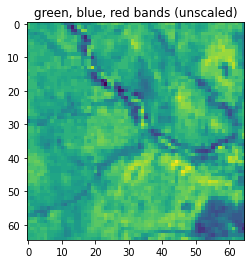

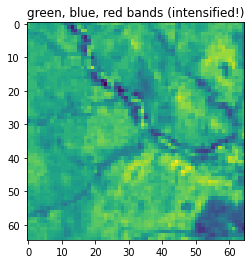

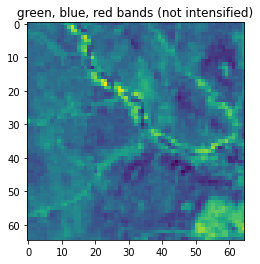

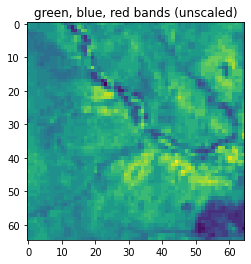

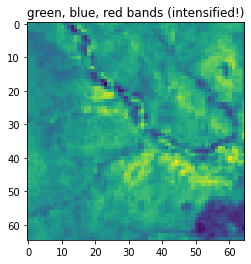

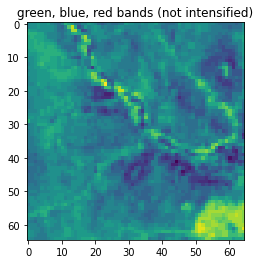

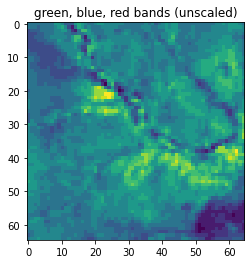

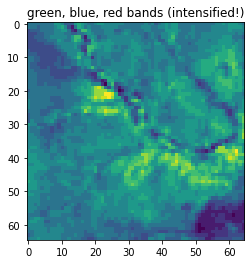

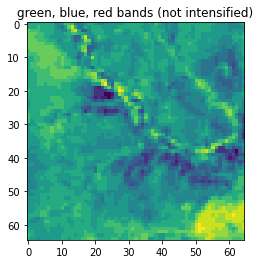

In [69]:


# get_img_from_example requires dictionary as input
imgarray, label = get_img_from_example(parsed_examples[0], intensify=False)


[[53 49 49 ... 54 52 46]
 [52 50 49 ... 52 53 45]
 [47 49 49 ... 49 51 46]
 ...
 [50 50 51 ... 42 36 35]
 [49 49 50 ... 42 41 42]
 [49 50 50 ... 48 47 46]] (65, 65)
[[37 36 36 ... 40 39 36]
 [37 36 36 ... 39 39 36]
 [34 35 35 ... 38 38 36]
 ...
 [35 36 37 ... 32 29 29]
 [35 36 37 ... 32 31 32]
 [36 37 38 ... 34 34 33]] (65, 65)
[[33 33 33 ... 35 34 33]
 [33 33 33 ... 35 35 34]
 [31 32 32 ... 34 34 34]
 ...
 [33 33 34 ... 31 30 30]
 [32 33 34 ... 31 31 31]
 [33 34 34 ... 32 32 31]] (65, 65)


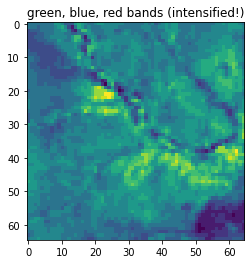

In [63]:
# get_img_from_example requires dictionary as input
imgarray, label = get_img_from_example(parsed_examples[0], intensify=True)

In [51]:
imgarray

array([[[211, 200, 205],
        [195, 195, 205],
        [195, 195, 205],
        ...,
        [215, 217, 217],
        [207, 211, 211],
        [183, 195, 205]],

       [[207, 200, 205],
        [199, 195, 205],
        [195, 195, 205],
        ...,
        [207, 211, 217],
        [211, 211, 217],
        [179, 195, 211]],

       [[187, 184, 192],
        [195, 189, 199],
        [195, 189, 199],
        ...,
        [195, 206, 211],
        [203, 206, 211],
        [183, 195, 211]],

       ...,

       [[199, 189, 205],
        [199, 195, 205],
        [203, 200, 211],
        ...,
        [167, 173, 192],
        [143, 157, 186],
        [139, 157, 186]],

       [[195, 189, 199],
        [195, 195, 205],
        [199, 200, 211],
        ...,
        [167, 173, 192],
        [163, 168, 192],
        [167, 173, 192]],

       [[195, 195, 205],
        [199, 200, 211],
        [199, 206, 211],
        ...,
        [191, 184, 199],
        [187, 184, 199],
        [183, 179, 192]]

# FUNCTION: Load images from GCP and process them

In [ ]:
## load blobs in for loop
def get_images_gcp(n=500):
    '''
    This function gets images from the cloud in the correct format.
    The function downloads images into temporary files, does a transformation, and then deletes the temporary file.
    '''
    
    # GCP bucket parameters
    project_name = 'drought-detection'
    bucket_name = 'wagon-data-batch913-drought_detection'

    # open client and get blobs
    storage_client = storage.Client(project=project_name)
    blobs = storage_client.list_blobs(bucket_name, 
                                      prefix='data/train/part', # what do file names start with
                                      delimiter='/', # don't include subdirectories
                                      max_results=n) # max number of blobs to grab
    
    images = []

    for blob in blobs:
        # create temporary file
        _, temp_local_filename = tempfile.mkstemp()

        # Download blob from bucket into temp file
        blob.download_to_filename(temp_local_filename)
        # temp_local_filename = blob.download_as_bytes() # tried downloading TFRecords in different format (as bytes)
        
        # Do stuff to file (transform data format)
        parsed_img = parse_visual(temp_local_filename) # parse satellite image data
        img_sat = get_img_from_example(parsed_img[0]) # convert data to rgbArray with label

        # append image (as 3D matrix) to list
        images.append(img_sat)
        
        # remove temporary file
        os.remove(temp_local_filename)
        
    return np.array(images)


# Check shape of get_images_gcp() output

# format

output is in format: images[satellie image number][0 = 3D image matrix / 1 = label] 

the first index refers to the satellite image number (length depends on how many images you chose to)


In [ ]:
# load images
images = get_images_gcp(n=5)

In [ ]:
# check shape of variable
images.shape # images[sat_img_num][0=3D image matrix/1=label]

In [ ]:
# check first image
images[0] # images[sat_img_num][0=3D image matrix/1=label]

In [ ]:
# check shape of first image's data
images[0].shape # images[sat_img_num][0=3D image matrix/1=label]

In [ ]:
# check shape of first image's size/dimensions (65 pixels x 65 pixels x 3 bands(?))
images[0][0].shape # images[sat_img_num][0=3D image matrix/1=label]


In [ ]:
# check label for first image
images[0][1] # images[sat_img_num][0=3D image matrix/1=label]

# Plot output from get_images_gcp()

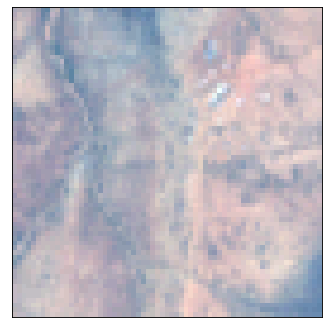

In [36]:
import matplotlib.pyplot as plt

# single image
fig=plt.figure(figsize=(5, 10), dpi= 80, facecolor='w', edgecolor='k')

# image has been preprocessed (image is from blobs in cloud)
img = images[15][0]

plt.imshow(img).axes.get_xaxis().set_visible(False)
plt.imshow(img).axes.get_yaxis().set_visible(False)
# plt.title(str(label))